In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [9]:
# Display the settings
pd.set_option('display.max_columns', 50)

#Load the dataset 
dataPATH = "Marital satisfaction_Data.csv"   # change path if needed
rawDF = pd.read_csv(dataPATH)

print(rawDF.shape)
rawDF.head()

(7180, 31)


,Country,"Sex (1-M, 2-F)",Age,Marriage duration (years),Number of children,Number of brought up children,"Education (1-no formal education, 2-primary school, 3-secondary school, 4-high school or technical college, 5-bachelor or master degree)","Material status (1-much better than average in my country, 2-better than average in my country, 3-similar to average in my country, 4-worse than average in my country, 5-much worse than average in my country)","Religion (1-Protestant, 2-Catholic, 3-Jewish, 4-Muslim, 5-Buddhist, 6-None, 7-Jehovah, 8-Evangelic, 9-Spiritualism, 10-Other - very specific, 11-Orthodox, 12-Hinduism)","Religiosity (1-not religious at all, 7-extremely religious)","Pension (1-strongly agree, 4-neither agree nor disagree, 7-strongly disagree)","Marriage and Relationships Questionnaire (MRQ) (1-yes, 3-neither yes nor no, 5-no)",Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,"Kansas Marital Satisfaction Scale (KMSS) (1-very dissatisfied, 7-very satisfied)",Unnamed: 21,Unnamed: 22,"Collectivism-Individualism (GLOBE survey) (1-strongly agree, 4-neither agree nor disagree, 7-strongly disagree)",Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30
0,Item number,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,1,2.0,3.0,4.0,1,2.0,3.0,4.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,National level,NaN,NaN,NaN,Individual level,NaN,NaN,NaN
2,Brazil,1.0,21.0,2.0,0.0,0.0,5.0,3.0,1.0,4.0,4.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,7.0,7.0,7.0,1,1.0,1.0,1.0,1,1.0,1.0,1.0
3,Brazil,1.0,29.0,3.0,1.0,0.0,5.0,3.0,1.0,6.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,6.0,6.0,6.0,2,1.0,1.0,1.0,1,1.0,1.0,1.0
4,Brazil,1.0,30.0,7.0,0.0,0.0,5.0,3.0,1.0,4.0,4.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,3.0,1.0,7.0,7.0,7.0,2,1.0,2.0,1.0,1,1.0,1.0,1.0


In [10]:

df = rawDF.iloc[2:].reset_index(drop=True)

print(df.shape)
df.head()

(7178, 31)


,Country,"Sex (1-M, 2-F)",Age,Marriage duration (years),Number of children,Number of brought up children,"Education (1-no formal education, 2-primary school, 3-secondary school, 4-high school or technical college, 5-bachelor or master degree)","Material status (1-much better than average in my country, 2-better than average in my country, 3-similar to average in my country, 4-worse than average in my country, 5-much worse than average in my country)","Religion (1-Protestant, 2-Catholic, 3-Jewish, 4-Muslim, 5-Buddhist, 6-None, 7-Jehovah, 8-Evangelic, 9-Spiritualism, 10-Other - very specific, 11-Orthodox, 12-Hinduism)","Religiosity (1-not religious at all, 7-extremely religious)","Pension (1-strongly agree, 4-neither agree nor disagree, 7-strongly disagree)","Marriage and Relationships Questionnaire (MRQ) (1-yes, 3-neither yes nor no, 5-no)",Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,"Kansas Marital Satisfaction Scale (KMSS) (1-very dissatisfied, 7-very satisfied)",Unnamed: 21,Unnamed: 22,"Collectivism-Individualism (GLOBE survey) (1-strongly agree, 4-neither agree nor disagree, 7-strongly disagree)",Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30
0,Brazil,1.0,21.0,2.0,0.0,0.0,5.0,3.0,1.0,4.0,4.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,7.0,7.0,7.0,1,1.0,1.0,1.0,1,1.0,1.0,1.0
1,Brazil,1.0,29.0,3.0,1.0,0.0,5.0,3.0,1.0,6.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,6.0,6.0,6.0,2,1.0,1.0,1.0,1,1.0,1.0,1.0
2,Brazil,1.0,30.0,7.0,0.0,0.0,5.0,3.0,1.0,4.0,4.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,3.0,1.0,7.0,7.0,7.0,2,1.0,2.0,1.0,1,1.0,1.0,1.0
3,Brazil,1.0,30.0,7.0,1.0,1.0,5.0,3.0,1.0,6.0,7.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,6.0,6.0,6.0,3,1.0,1.0,2.0,1,1.0,1.0,1.0
4,Brazil,1.0,28.0,9.0,0.0,0.0,4.0,2.0,1.0,5.0,7.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,7.0,6.0,7.0,3,2.0,3.0,2.0,1,1.0,1.0,1.0


In [51]:
# 3. RENAME COLUMNS TO SIMPLER NAMES
# We will use the positions of columns to build a clean name map.

origCols = df.columns.tolist()
for i, c in enumerate(origCols):
    print(i, "->", c)

# Manually map key the descriptive columns, then map the grouped scales
renameDict = {
    origCols[0]:  'country',
    origCols[1]:  'sex',              # 1 = Male, 2 = Female
    origCols[2]:  'age',
    origCols[3]:  'marriage_years',
    origCols[4]:  'num_children',
    origCols[5]:  'num_brought_up_children',
    origCols[6]:  'education',
    origCols[7]:  'material_status',
    origCols[8]:  'religion',
    origCols[9]:  'religiosity',
    origCols[10]: 'pension_belief',
}

# Marriage and Relationship Questionnaire(MRQ): columns 11–19 (9 items)
mrqCols = origCols[11:20]
for i, col in enumerate(mrqCols, start=1):
    renameDict[col] = f'mrq_q{i}'   # mrq_q1 ... mrq_q9

#Kansas Marital Satisfaction Scale (KMSS): columns 20–22 (3 items)
kmssCols = origCols[20:23]
for i, col in enumerate(kmssCols, start=1):
    renameDict[col] = f'kmss_q{i}'  # kmss_q1 ... kmss_q3

#Collectivism-Individualism(GLOBE survey): columns 23–30 (8 items)
globeCols = origCols[23:31]
for i, col in enumerate(globeCols, start=1):
    renameDict[col] = f'globe_q{i}'  # globe_q1 ... globe_q8

# renames the columns
df = df.rename(columns=renameDict)

df.head()


0 -> country
1 -> sex
2 -> age
3 -> marriage_years
4 -> num_children
5 -> num_brought_up_children
6 -> education
7 -> material_status
8 -> religion
9 -> religiosity
10 -> pension_belief
11 -> mrq_q1
12 -> mrq_q2
13 -> mrq_q3
14 -> mrq_q4
15 -> mrq_q5
16 -> mrq_q6
17 -> mrq_q7
18 -> mrq_q8
19 -> mrq_q9
20 -> kmss_q1
21 -> kmss_q2
22 -> kmss_q3
23 -> globe_q1
24 -> globe_q2
25 -> globe_q3
26 -> globe_q4
27 -> globe_q5
28 -> globe_q6
29 -> globe_q7
30 -> globe_q8
31 -> kmss_mean
32 -> satisfied
33 -> mrq_mean
34 -> globe_mean


,country,sex,age,marriage_years,num_children,num_brought_up_children,education,material_status,religion,religiosity,pension_belief,mrq_q1,mrq_q2,mrq_q3,mrq_q4,mrq_q5,mrq_q6,mrq_q7,mrq_q8,mrq_q9,kmss_q1,kmss_q2,kmss_q3,globe_q1,globe_q2,globe_q3,globe_q4,globe_q5,globe_q6,globe_q7,globe_q8,kmss_mean,satisfied,mrq_mean,globe_mean
0,Brazil,1.0,21.0,2.0,0.0,0.0,5.0,3.0,1.0,4.0,4.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,7.0,7.0,7.0,1,1.0,1.0,1.0,1,1.0,1.0,1.0,7.000000,1,1.222222,1.000
1,Brazil,1.0,29.0,3.0,1.0,0.0,5.0,3.0,1.0,6.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,6.0,6.0,6.0,2,1.0,1.0,1.0,1,1.0,1.0,1.0,6.000000,1,1.111111,1.125
2,Brazil,1.0,30.0,7.0,0.0,0.0,5.0,3.0,1.0,4.0,4.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,3.0,1.0,7.0,7.0,7.0,2,1.0,2.0,1.0,1,1.0,1.0,1.0,7.000000,1,1.333333,1.250
3,Brazil,1.0,30.0,7.0,1.0,1.0,5.0,3.0,1.0,6.0,7.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,6.0,6.0,6.0,3,1.0,1.0,2.0,1,1.0,1.0,1.0,6.000000,1,1.222222,1.375
4,Brazil,1.0,28.0,9.0,0.0,0.0,4.0,2.0,1.0,5.0,7.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,7.0,6.0,7.0,3,2.0,3.0,2.0,1,1.0,1.0,1.0,6.666667,1,1.222222,1.750


In [53]:
# 4. CREATE TARGET VARIABLES, KMSS mean score (continuous satisfaction) and Binary satisfaction label
# Convert KMSS columns to numeric just in case there are coerce errors to NaN
kmssItems = ['kmss_q1', 'kmss_q2', 'kmss_q3']
df[kmssItems] = df[kmssItems].apply(pd.to_numeric, errors='coerce')

# Create mean satisfaction score
df['kmss_mean'] = df[kmssItems].mean(axis=1)

# Drop rows with missing target
df = df.dropna(subset=['kmss_mean']).reset_index(drop=True)

# Create a binary label--> 1 = satisfied (>=5), 0 = not satisfied (<5)
df['satisfied'] = (df['kmss_mean'] >= 5).astype(int)

df[['kmss_q1', 'kmss_q2', 'kmss_q3', 'kmss_mean', 'satisfied']].head()


,kmss_q1,kmss_q2,kmss_q3,kmss_mean,satisfied
0,7.0,7.0,7.0,7.000000,1
1,6.0,6.0,6.0,6.000000,1
2,7.0,7.0,7.0,7.000000,1
3,6.0,6.0,6.0,6.000000,1
4,7.0,6.0,7.0,6.666667,1


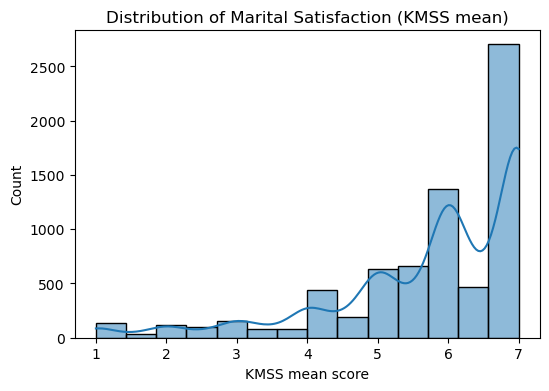

satisfied
1    0.814154
0    0.185846
Name: proportion, dtype: float64

In [44]:
# 5. QUICK EDA | Distribution of satisfaction and Some basic relationships

plt.figure(figsize=(6,4))
sns.histplot(df['kmss_mean'], kde=True, bins=14)
plt.title('Distribution of Marital Satisfaction (KMSS mean)')
plt.xlabel('KMSS mean score')
plt.ylabel('Count')
plt.show()

# Class balance (binary satisfaction)
df['satisfied'].value_counts(normalize=True)


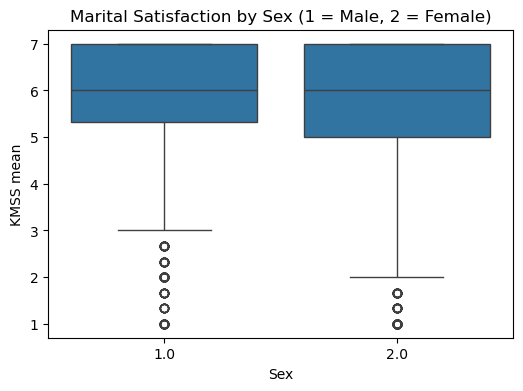

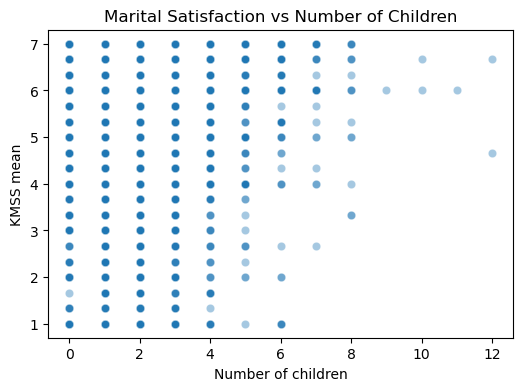

In [45]:
# Satisfaction by sex
plt.figure(figsize=(6,4))
sns.boxplot(x='sex', y='kmss_mean', data=df)
plt.title('Marital Satisfaction by Sex (1 = Male, 2 = Female)')
plt.xlabel('Sex')
plt.ylabel('KMSS mean')
plt.show()

# Satisfaction by number of children
plt.figure(figsize=(6,4))
sns.scatterplot(x='num_children', y='kmss_mean', data=df, alpha=0.4)
plt.title('Marital Satisfaction vs Number of Children')
plt.xlabel('Number of children')
plt.ylabel('KMSS mean')
plt.show()


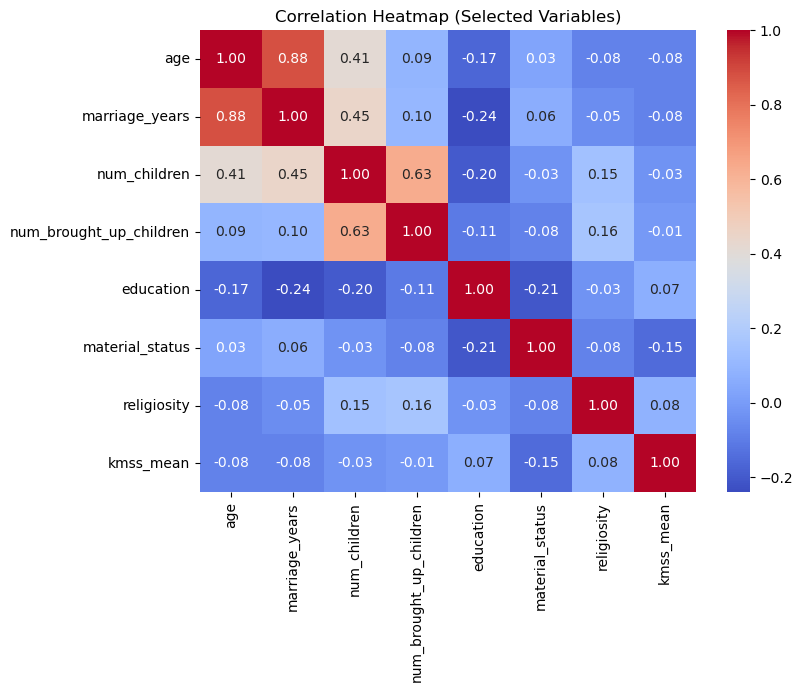

In [46]:
# Correlation heatmap for selected numeric features
numericColsSample = [
    'age', 'marriage_years', 'num_children', 'num_brought_up_children',
    'education', 'material_status', 'religiosity', 'kmss_mean'
]

corr = df[numericColsSample].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap (Selected Variables)')
plt.show()


In [47]:
# 6. FEATURE ENGINEERING, Create composite scores for MRQ and GLOBE and Prepare feature matrix X and targets (classification and regression)

mrqItems = [col for col in df.columns if col.startswith('mrq_q')]
globeItems = [col for col in df.columns if col.startswith('globe_q')]

# Ensure numeric
df[mrqItems + globeItems] = df[mrqItems + globeItems].apply(pd.to_numeric, errors='coerce')

# Composite scores
df['mrq_mean'] = df[mrqItems].mean(axis=1)
df['globe_mean'] = df[globeItems].mean(axis=1)

# Choose features: drop country and KMSS items + target columns
dropCols = ['country'] + kmssItems + ['kmss_mean', 'satisfied']
featureCols = [col for col in df.columns if col not in dropCols]

print("Number of features:", len(featureCols))
featureCols


Number of features: 29


['sex',
 'age',
 'marriage_years',
 'num_children',
 'num_brought_up_children',
 'education',
 'material_status',
 'religion',
 'religiosity',
 'pension_belief',
 'mrq_q1',
 'mrq_q2',
 'mrq_q3',
 'mrq_q4',
 'mrq_q5',
 'mrq_q6',
 'mrq_q7',
 'mrq_q8',
 'mrq_q9',
 'globe_q1',
 'globe_q2',
 'globe_q3',
 'globe_q4',
 'globe_q5',
 'globe_q6',
 'globe_q7',
 'globe_q8',
 'mrq_mean',
 'globe_mean']

In [48]:
# Prepare X, y for classification and regression
X = df[featureCols]

# Classification target (binary)
y_class = df['satisfied']

# Regression target (continuous satisfaction)
y_reg = df['kmss_mean']

# Train-test split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_class, test_size=0.3, random_state=42, stratify=y_class
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.3, random_state=42
)

X_train_cls.shape, X_test_cls.shape


((5024, 29), (2154, 29))

In [39]:
# 7. PREPROCESSING PIPELINE, Imputes missing values (median) and Standardize features

numericTransformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])



In [36]:
# 8. CLASSIFICATION MODELS
# - RandomForestClassifier
# - KNeighborsClassifier
# - DecisionTreeClassifier
# - SVM (SVC)


from collections import OrderedDict

classificationModels = OrderedDict({
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=7
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=None, random_state=42
    ),
    "SVM": SVC(
        kernel='rbf', probability=True, random_state=42
    )
})



=== Random Forest ===
Accuracy : 0.885
Precision: 0.900
Recall   : 0.966
F1-score : 0.932
AUC      : 0.883

Classification Report:
              precision    recall  f1-score   support

           0      0.779     0.530     0.631       400
           1      0.900     0.966     0.932      1754

    accuracy                          0.885      2154
   macro avg      0.840     0.748     0.781      2154
weighted avg      0.878     0.885     0.876      2154



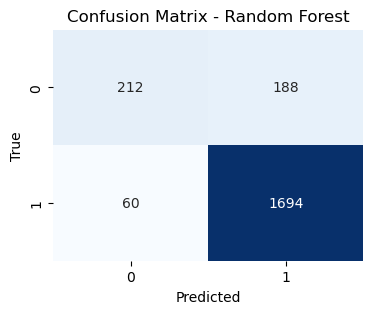

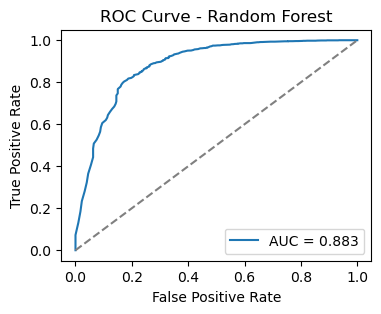


=== KNN ===
Accuracy : 0.872
Precision: 0.881
Recall   : 0.974
F1-score : 0.925
AUC      : 0.808

Classification Report:
              precision    recall  f1-score   support

           0      0.790     0.422     0.550       400
           1      0.881     0.974     0.925      1754

    accuracy                          0.872      2154
   macro avg      0.835     0.698     0.738      2154
weighted avg      0.864     0.872     0.856      2154



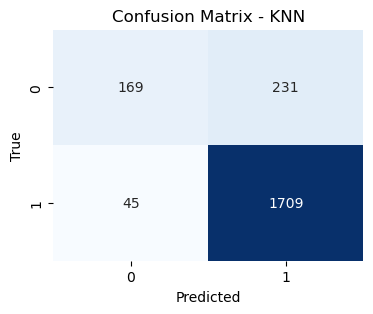

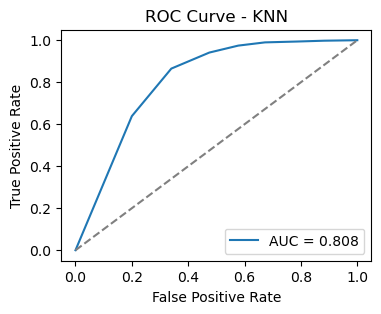


=== Decision Tree ===
Accuracy : 0.824
Precision: 0.894
Recall   : 0.889
F1-score : 0.892
AUC      : 0.714

Classification Report:
              precision    recall  f1-score   support

           0      0.526     0.540     0.533       400
           1      0.894     0.889     0.892      1754

    accuracy                          0.824      2154
   macro avg      0.710     0.714     0.712      2154
weighted avg      0.826     0.824     0.825      2154



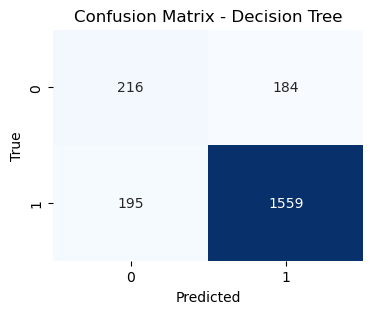

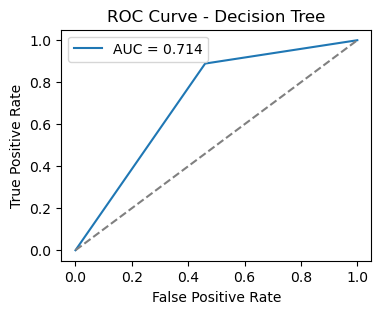


=== SVM ===
Accuracy : 0.883
Precision: 0.894
Recall   : 0.973
F1-score : 0.931
AUC      : 0.846

Classification Report:
              precision    recall  f1-score   support

           0      0.804     0.492     0.611       400
           1      0.894     0.973     0.931      1754

    accuracy                          0.883      2154
   macro avg      0.849     0.733     0.771      2154
weighted avg      0.877     0.883     0.872      2154



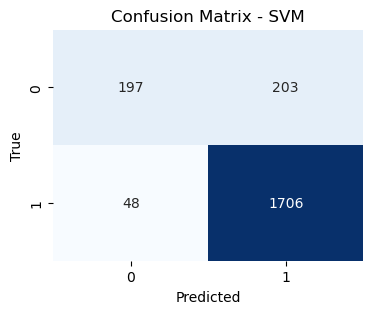

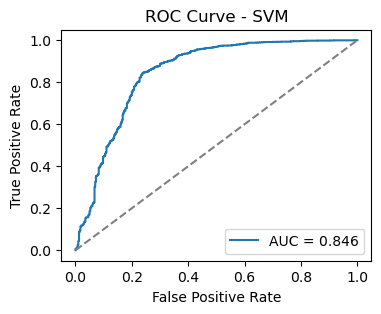

In [38]:
# Train and evaluate all classification models
resultsCls = {}

for name, model in classificationModels.items():
    metrics = evaluate_classification_model(
        name, model,
        X_train_cls, y_train_cls,
        X_test_cls, y_test_cls
    )
    resultsCls[name] = metrics


In [50]:
# 9. REGRESSION MODEL
# - Linear Regression was used to predict continuous satisfaction (kmss_mean)


regressionModel = LinearRegression()

regPipe = Pipeline(steps=[
    ('preprocess', numericTransformer),
    ('model', regressionModel)
])

regPipe.fit(X_train_reg, y_train_reg)

y_pred_reg = regPipe.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("=== Linear Regression (KMSS mean) ===")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2 : {r2:.33f}")


=== Linear Regression (KMSS mean) ===
MAE : 0.707
RMSE: 1.011
R^2 : 0.483615767901603543776900551165454


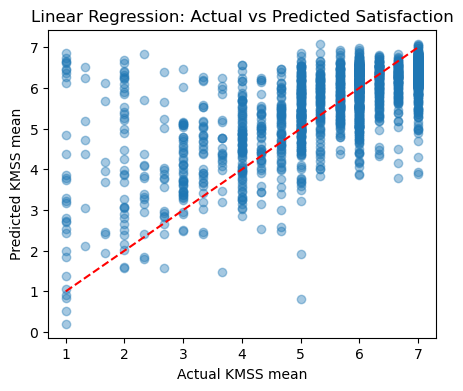

In [24]:
# Plot predicted vs actual satisfaction for Linear Regression
plt.figure(figsize=(5,4))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4)
plt.xlabel("Actual KMSS mean")
plt.ylabel("Predicted KMSS mean")
plt.title("Linear Regression: Actual vs Predicted Satisfaction")
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--')
plt.show()


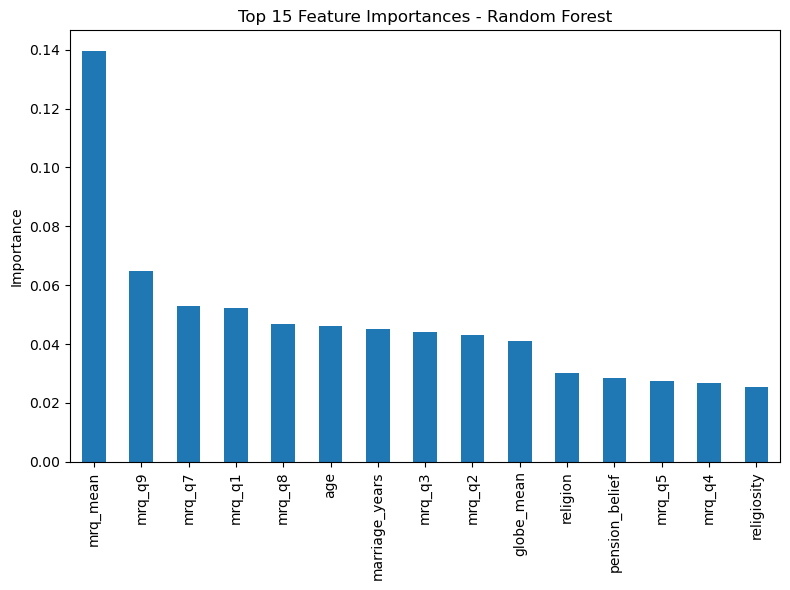

mrq_mean                   0.139589
mrq_q9                     0.064648
mrq_q7                     0.052860
mrq_q1                     0.052343
mrq_q8                     0.046741
age                        0.046184
marriage_years             0.044970
mrq_q3                     0.044179
mrq_q2                     0.043201
globe_mean                 0.041151
religion                   0.030057
pension_belief             0.028354
mrq_q5                     0.027301
mrq_q4                     0.026728
religiosity                0.025467
globe_q7                   0.025294
globe_q3                   0.025002
globe_q8                   0.023597
mrq_q6                     0.022692
num_brought_up_children    0.022156
dtype: float64

In [49]:
# 10. FEATURE IMPORTANCE (Random Forest) Used to understand what predicts satisfaction

# Refit Random Forest on full data (classification) to get feature importances
rf = RandomForestClassifier(n_estimators=300, random_state=42)

rfPipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    # No scaler needed for RF
    ('model', rf)
])

rfPipe.fit(X, y_class)

# Extract the trained model
rfTrained = rfPipe.named_steps['model']

importances = rfTrained.feature_importances_
featImportances = pd.Series(importances, index=featureCols).sort_values(ascending=False)

plt.figure(figsize=(8,6))
featImportances.head(15).plot(kind='bar')
plt.title("Top 15 Feature Importances - Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

featImportances.head(20)
